# Homework 1
Univariate linear regression with gradient descent and logistic regression

## 1 - Univariate linear regression with gradient descent

**Step 1**  
I calculated the derivatives of L with respect to w0 and w1.  
I got -2 and -2x.

**Step 2**  
I will write an algorithm which can update the weights (w0, w1) by going in the opposite direction of the gradient with steps of size lr.

In [1]:
def predict(w0, w1, x):
    return w0 + w1 * x

In [2]:
def calculate_gradient(x, y, w0, w1):
    y_pred = predict(w0, w1, x)

    L1 = 1/len(x) * (sum(-2 * (y - (y_pred)))) # I got -2 from step 1
    L2 = 1/len(x) * (sum(-2 * x * (y - (y_pred)))) # I got -2x from step 1
    
    return (L1, L2)

In [3]:
def update(x, y, w0, w1, lr):
    L1, L2 = calculate_gradient(x, y, w0, w1)

    # This is where we step in the opposite direction of the gradient
    w0 -= lr * L1
    w1 -= lr * L2

    return w0, w1

In [4]:
def loop(x, y, it, lr):
    w0, w1 = 0, 0

    for _ in range(it):
        w0, w1 = update(x, y, w0, w1, lr)

    return w0, w1

**Step 3**  
I will use my algorithm to learn the datset.

In [5]:
import numpy as np

data = np.loadtxt('unilinear.csv', delimiter=',', skiprows=1)
x = data[:, 0]
y = data[:, 1]

w0, w1 = loop(x, y, it=40, lr=0.1)

print(w0, w1)

6.155614169309017 5.300224937809824


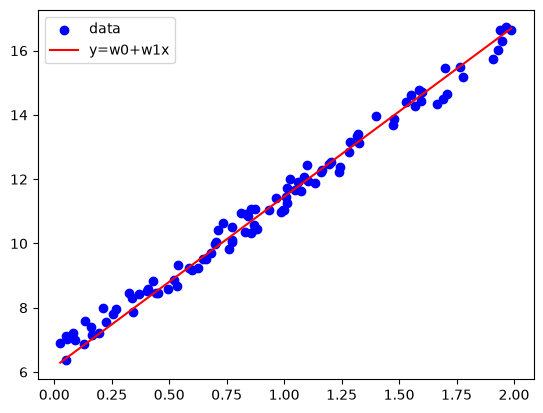

In [6]:
import matplotlib.pyplot as plt

x_sorted = np.sort(x)
y_pred = predict(w0, w1, x_sorted)

plt.scatter(x, y, color='blue', label='data')
plt.plot(x_sorted, y_pred, color='red', label='y=w0+w1x')
plt.legend()
plt.show()

The line fits the datapoints very well.

**Step 4**  
I will compute the exact closed form solution with Moore-Penrose and compare it to the approximate solution I got with gradient descent.

In [7]:
matrix = np.column_stack((np.ones_like(x), x))

pinv = np.linalg.pinv(matrix)

w0_exact, w1_exact = pinv.dot(y)

print(w0_exact, w1_exact)

6.454787089540192 5.021290388929581


In [8]:
print(abs(w0-w0_exact), abs(w1-w1_exact))

0.29917292023117437 0.27893454888024305


I can se that the difference between my solution and the exact solution is quite small. I will now try to up the number of iterations and see if I can close the gap.

In [9]:
w0_hi_it, w1_hi_it = loop(x, y, it=400, lr=0.1)
print(abs(w0_hi_it-w0_exact), abs(w1_hi_it-w1_exact))


9.23694885912596e-06 8.612090709014808e-06


After 400 iterations the gap is very very small.

**Step 5**  
I will now try to use different values for my learning rate to see what happens.

In [10]:
lrs = [0.0001, 0.001, 0.01, 0.1, 1.0]

for lr in lrs:
    w0_lr, w1_lr = loop(x, y, it=40, lr=lr)
    print(f"{lr}: {float(abs(w0_lr-w0_exact)), float(abs(w1_lr-w1_exact))}")

0.0001: (6.366865164896913, 4.929151274933828)
0.001: (5.633396888179292, 4.161816599573652)
0.01: (1.9340724723559424, 0.37732307045252433)
0.1: (0.29917292023117437, 0.27893454888024305)
1.0: (4.702128935036877e+19, 5.043296220380709e+19)


Learning rate refers to the step size of the steps we take in gradient descent.  
Too big of a learning rate jumps over the local minima, too small of a learning rate never reaches it. A small learning rate can reach the local minima if the number of iterations is high enough.  
I can see that for this case, with 40 iterations, the best learning rate lies somewhere in the neighborhood of 0.1.

## 2 - Logistic regression

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

X, y = iris.data[:, 3], iris.target # I think this is the feature I should use

print(X, y)

[0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 0.2 0.2 0.1 0.1 0.2 0.4 0.4 0.3
 0.3 0.3 0.2 0.4 0.2 0.5 0.2 0.2 0.4 0.2 0.2 0.2 0.2 0.4 0.1 0.2 0.2 0.2
 0.2 0.1 0.2 0.2 0.3 0.3 0.2 0.6 0.4 0.3 0.2 0.2 0.2 0.2 1.4 1.5 1.5 1.3
 1.5 1.3 1.6 1.  1.3 1.4 1.  1.5 1.  1.4 1.3 1.4 1.5 1.  1.5 1.1 1.8 1.3
 1.5 1.2 1.3 1.4 1.4 1.7 1.5 1.  1.1 1.  1.2 1.6 1.5 1.6 1.5 1.3 1.3 1.3
 1.2 1.4 1.2 1.  1.3 1.2 1.3 1.3 1.1 1.3 2.5 1.9 2.1 1.8 2.2 2.1 1.7 1.8
 1.8 2.5 2.  1.9 2.1 2.  2.4 2.3 1.8 2.2 2.3 1.5 2.3 2.  2.  1.8 2.1 1.8
 1.8 1.8 2.1 1.6 1.9 2.  2.2 1.5 1.4 2.3 2.4 1.8 1.8 2.1 2.4 2.3 1.9 2.3
 2.5 2.3 1.9 2.  2.3 1.8] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [19]:
from sklearn.model_selection import train_test_split

seed = 67

# I first split off a test set
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, train_size=0.85, test_size=0.15, stratify=y, random_state=seed)

# I then split off a validation set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=0.7/0.85, test_size=0.15/0.85, stratify=y_train_val, random_state=seed)


In [ ]:
from sklearn.linear_model import LinearRegression

ValueError: Expected 2D array, got 1D array instead:
array=[1.9 1.3 0.3 1.3 1.2 1.5 1.7 0.4 1.8 1.6 1.5 0.3 1.3 0.4 1.5 2.1 2.4 1.
 0.3 1.8 1.2 1.3 1.  0.3 0.2 0.2 1.6 1.9 1.8 1.6 0.1 0.3 1.  1.5 2.3 1.8
 2.  0.2 1.5 2.2 2.3 1.4 0.1 1.4 0.2 2.1 2.2 2.3 0.3 0.4 0.4 1.  0.2 1.1
 2.5 1.2 0.2 0.2 2.1 2.1 1.4 1.  0.2 2.2 0.2 1.3 1.9 0.5 1.4 0.2 1.7 1.8
 0.2 0.2 1.3 1.4 1.9 0.2 1.8 2.4 0.2 1.4 0.6 0.1 0.2 0.2 1.5 1.8 1.3 1.5
 0.2 2.  1.8 1.6 1.5 2.  1.  2.  1.3 2.4 0.2 0.2 0.4 1.8].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.